In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


In [2]:
# Load Dataset

print("\nLoading Dataset...")

df = pd.read_csv(
    "OnlineRetail.csv",
    encoding="ISO-8859-1"
)

print("Dataset Loaded Successfully")


Loading Dataset...
Dataset Loaded Successfully


In [3]:
# Dataset Overview

print("\nDataset Shape")
print(df.shape)

print("\nFirst Five Records")
display(df.head())

print("\nLast Five Records")
display(df.tail())

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)


Dataset Shape
(541909, 8)

First Five Records


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom



Last Five Records


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France



Column Names
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [4]:
# Basic Dataset Information

print("\nDataset Information")

df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Missing Values

print("\nMissing Values")

missing = df.isnull().sum()

missing_percent = round(
    (missing/len(df))*100,
    2
)

missing_table = pd.DataFrame({

    "Missing Values":missing,
    "Percentage":missing_percent

})

display(
    missing_table.sort_values(
        by="Missing Values",
        ascending=False
    )
)


Missing Values


,Missing Values,Percentage
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


In [6]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("\nDuplicate Rows :",duplicates)


Duplicate Rows : 5268


In [7]:
# Statistical Summary

print("\nNumerical Summary")

display(df.describe())

print("\nCategorical Summary")

display(df.describe(include="object"))


Numerical Summary


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000



Categorical Summary


,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [8]:
# Unique Values

print("\nUnique Values in Each Column")

for column in df.columns:

    print(column,":",df[column].nunique())


Unique Values in Each Column
InvoiceNo : 25900
StockCode : 4070
Description : 4223
Quantity : 722
InvoiceDate : 23260
UnitPrice : 1630
CustomerID : 4372
Country : 38


In [9]:
# Data Cleaning

print("\nCleaning Dataset")


Cleaning Dataset


In [10]:
# Remove Duplicate Records

df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [11]:
# Remove Missing Customer ID

df = df.dropna(subset=["CustomerID"])

print("Missing CustomerID Removed")

Missing CustomerID Removed


In [12]:
# Remove Missing Product Description

df = df.dropna(subset=["Description"])

print("Missing Description Removed")

Missing Description Removed


In [13]:
# Remove Negative Quantity

df = df[df["Quantity"]>0]

In [14]:
# Remove Zero Quantity

df = df[df["Quantity"]!=0]

In [15]:
# Remove Negative Price

df = df[df["UnitPrice"]>0]

print("Invalid Quantity & Price Removed")

Invalid Quantity & Price Removed


In [16]:
# Convert Data Types

print("\nFormatting Dataset")

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df["CustomerID"] = df["CustomerID"].astype(int)

print(df.dtypes)


Formatting Dataset
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object


In [17]:
# Feature Engineering

print("\nCreating New Features")


Creating New Features


In [18]:
# Transaction Value

df["Sales"] = df["Quantity"] * df["UnitPrice"]

In [19]:
# Date Features

df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["MonthName"] = df["InvoiceDate"].dt.month_name()

df["Day"] = df["InvoiceDate"].dt.day

df["Weekday"] = df["InvoiceDate"].dt.day_name()

df["Hour"] = df["InvoiceDate"].dt.hour

In [20]:
# Weekend Feature

df["Weekend"] = df["Weekday"].isin(
    ["Saturday","Sunday"]
).astype(int)

In [21]:
# Create Classification Target

print("\nCreating Target Variable")

median_sales = df["Sales"].median()

df["Purchase"] = np.where(

    df["Sales"] >= median_sales,
    1,
    0

)

print("Median Sales Value :",round(median_sales,2))

print("\nTarget Distribution")

display(
    df["Purchase"].value_counts()
)


Creating Target Variable
Median Sales Value : 12.45

Target Distribution


,count
Purchase,
1,196349
0,196343


In [22]:
# Dataset After Cleaning

print("\nDataset Shape After Cleaning")

print(df.shape)

print("\nRemaining Missing Values")

display(df.isnull().sum())

print("\nPreview of Cleaned Dataset")

display(df.head())


Dataset Shape After Cleaning
(392692, 17)

Remaining Missing Values


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Sales,0
Year,0



Preview of Cleaned Dataset


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Year,Month,MonthName,Day,Weekday,Hour,Weekend,Purchase
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,1,Wednesday,8,0,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,0,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,1,Wednesday,8,0,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,0,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,0,1


In [23]:
# Save Clean Dataset

df.to_csv(
    "OnlineRetail_Cleaned.csv",
    index=False
)

print("\nClean Dataset Saved Successfully")


Clean Dataset Saved Successfully


In [24]:
# Final Statistical Summary

print("\nSummary Statistics")

display(df.describe())


Summary Statistics


,Quantity,InvoiceDate,UnitPrice,CustomerID,Sales,Year,Month,Day,Hour,Weekend,Purchase
count,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532,0.155878,0.500008
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000,0.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000,0.000000,0.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000,0.000000,1.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000,0.000000,1.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000,1.000000,1.000000
std,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661,0.362740,0.500001


In [25]:
# Correlation Variables

numerical_columns = [

    "Quantity",
    "UnitPrice",
    "Sales",
    "Purchase"

]

print("\nCorrelation Matrix Values")

display(
    df[numerical_columns].corr()
)

print("Clean Dataset Shape :",df.shape)
print("Ready for Exploratory Data Analysis")


Correlation Matrix Values


,Quantity,UnitPrice,Sales,Purchase
Quantity,1.000000,-0.004578,0.914451,0.043377
UnitPrice,-0.004578,1.000000,0.081619,0.048508
Sales,0.914451,0.081619,1.000000,0.055702
Purchase,0.043377,0.048508,0.055702,1.000000


Clean Dataset Shape : (392692, 17)
Ready for Exploratory Data Analysis


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

In [27]:
# Load Clean Dataset

df = pd.read_csv("OnlineRetail_Cleaned.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset Shape :", df.shape)

Dataset Shape : (392692, 17)


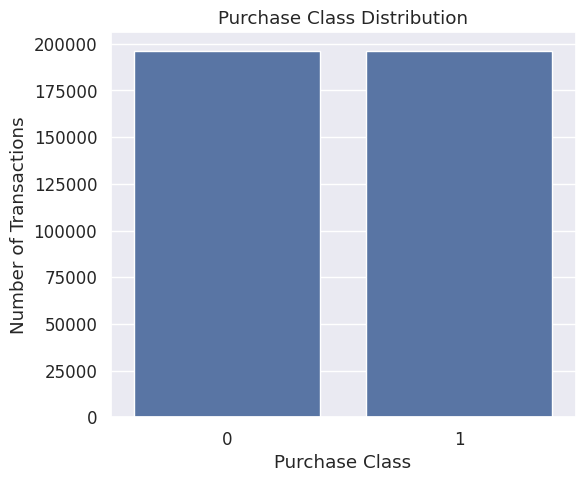

In [28]:
# 1. Purchase Class Distribution

plt.figure(figsize=(6,5))

sns.countplot(
    x="Purchase",
    data=df
)

plt.title("Purchase Class Distribution")
plt.xlabel("Purchase Class")
plt.ylabel("Number of Transactions")

plt.show()

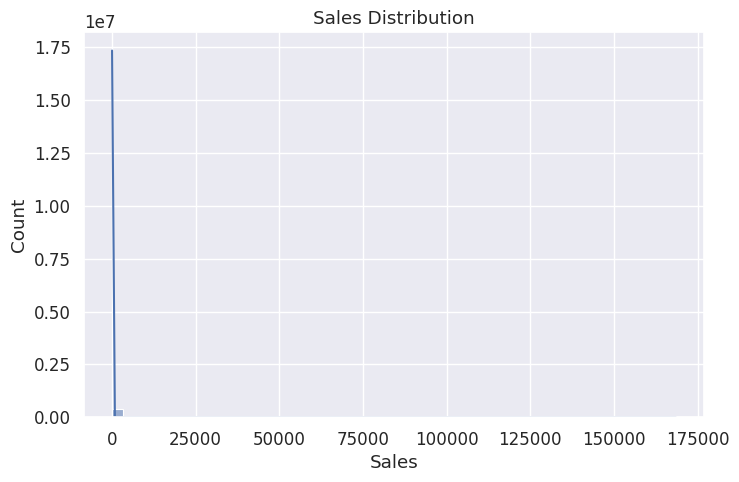

In [29]:
# 2. Sales Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=50,
    kde=True
)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.show()

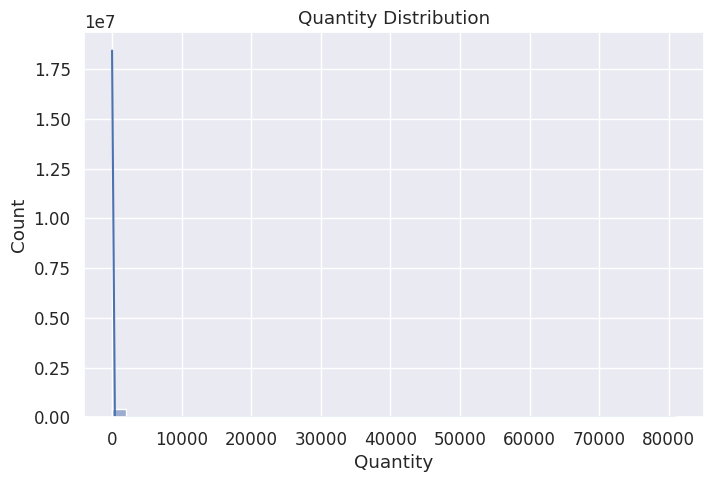

In [30]:
# 3. Quantity Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["Quantity"],
    bins=40,
    kde=True
)

plt.title("Quantity Distribution")

plt.show()

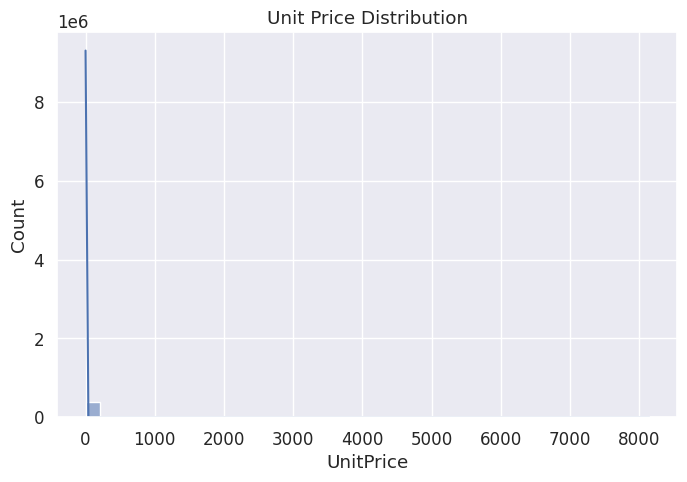

In [31]:
# 4. Unit Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df["UnitPrice"],
    bins=40,
    kde=True
)

plt.title("Unit Price Distribution")

plt.show()

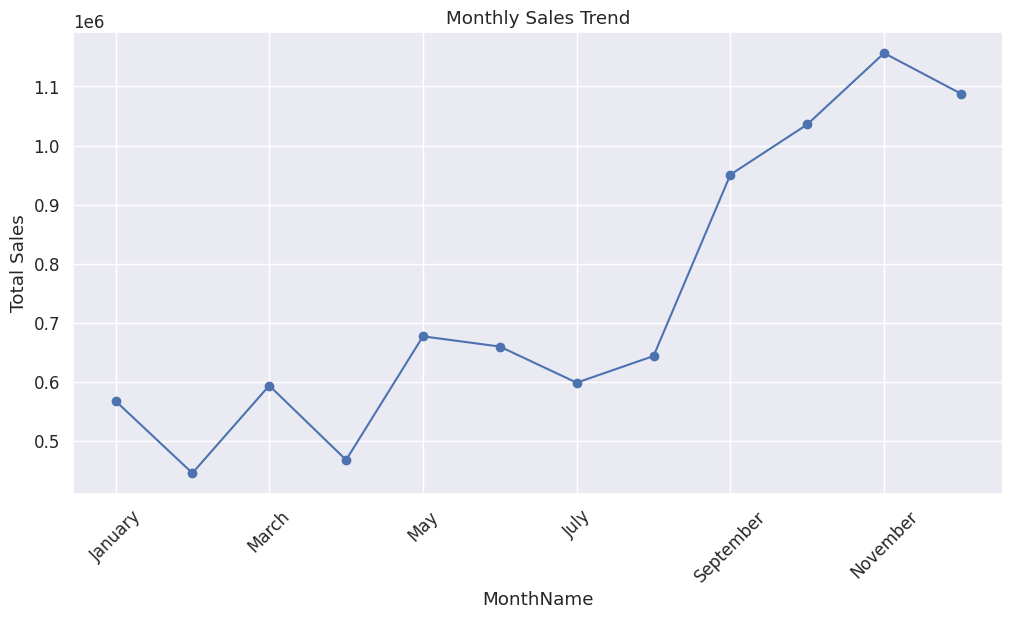

In [32]:
# 5. Monthly Sales Trend

monthly_sales = df.groupby(
    "MonthName"
)["Sales"].sum()

order = [

    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"

]

monthly_sales = monthly_sales.reindex(order)

plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

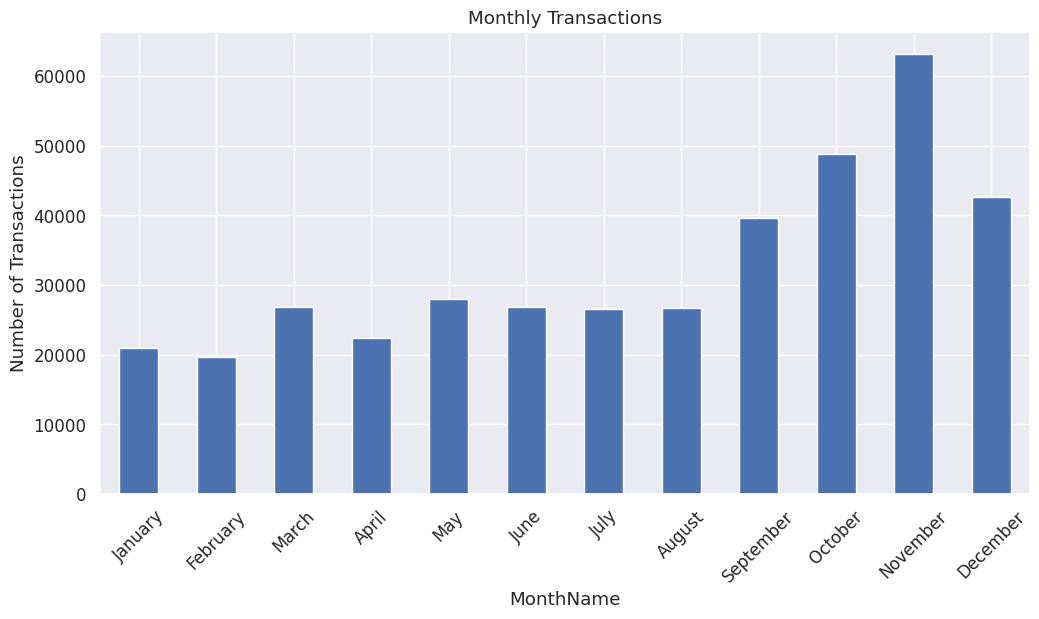

In [33]:
# 6. Monthly Transactions

monthly_transactions = df.groupby(
    "MonthName"
).size()

monthly_transactions = monthly_transactions.reindex(order)

plt.figure(figsize=(12,6))

monthly_transactions.plot(
    kind="bar"
)

plt.title("Monthly Transactions")

plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

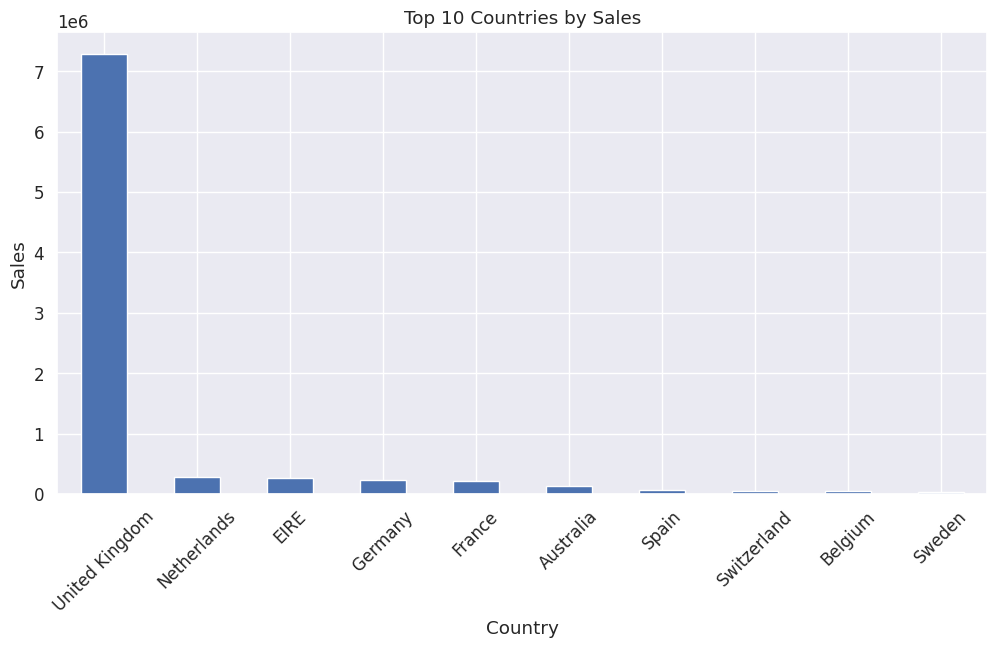


Top Countries


,Sales
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


In [34]:
# 7. Sales by Country

country_sales = df.groupby(
    "Country"
)["Sales"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

country_sales.plot(
    kind="bar"
)

plt.title("Top 10 Countries by Sales")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

print("\nTop Countries")

display(country_sales)

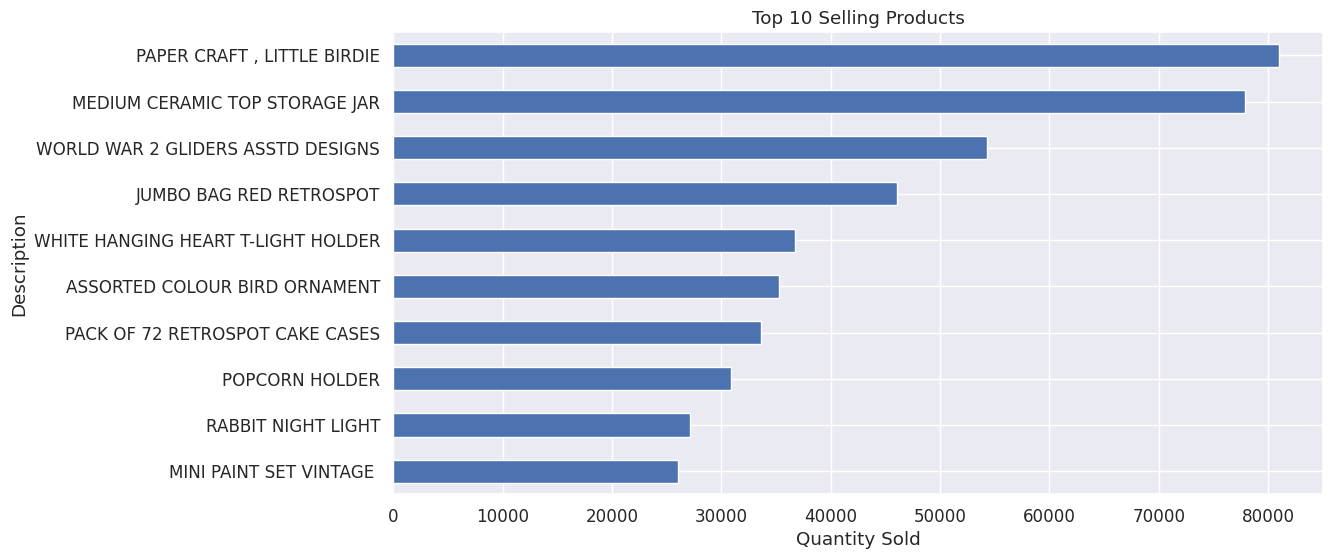

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


In [35]:
# 8. Top Selling Products

top_products = df.groupby(
    "Description"
)["Quantity"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_products.plot(
    kind="barh"
)

plt.title("Top 10 Selling Products")

plt.xlabel("Quantity Sold")

plt.gca().invert_yaxis()

plt.show()

display(top_products)

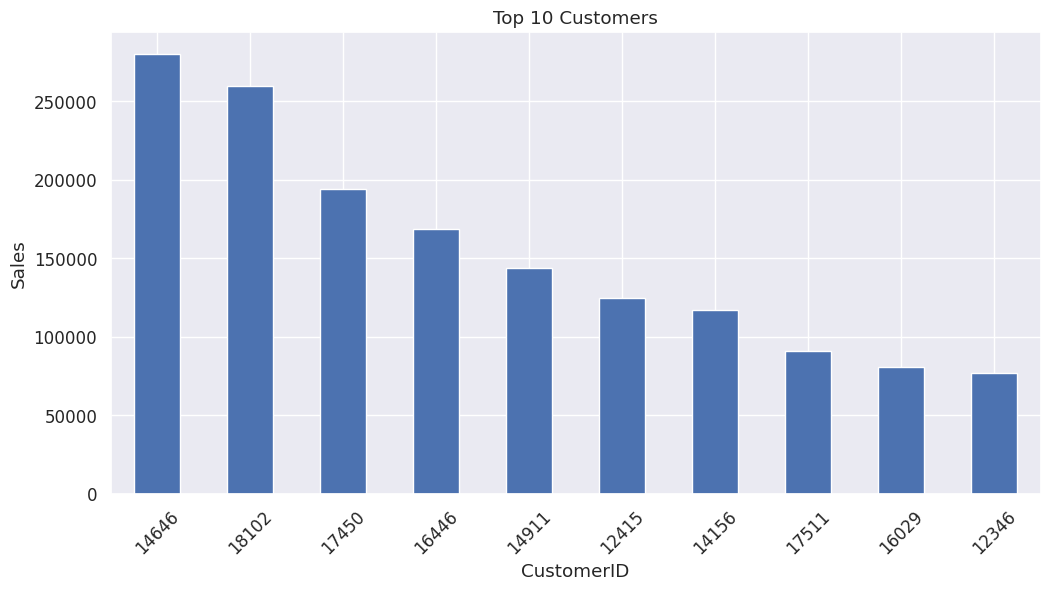

,Sales
CustomerID,
14646,280206.02
18102,259657.30
17450,194390.79
16446,168472.50
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,80850.84


In [36]:
# 9. Top Customers

top_customers = df.groupby(
    "CustomerID"
)["Sales"].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_customers.plot(
    kind="bar"
)

plt.title("Top 10 Customers")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

display(top_customers)

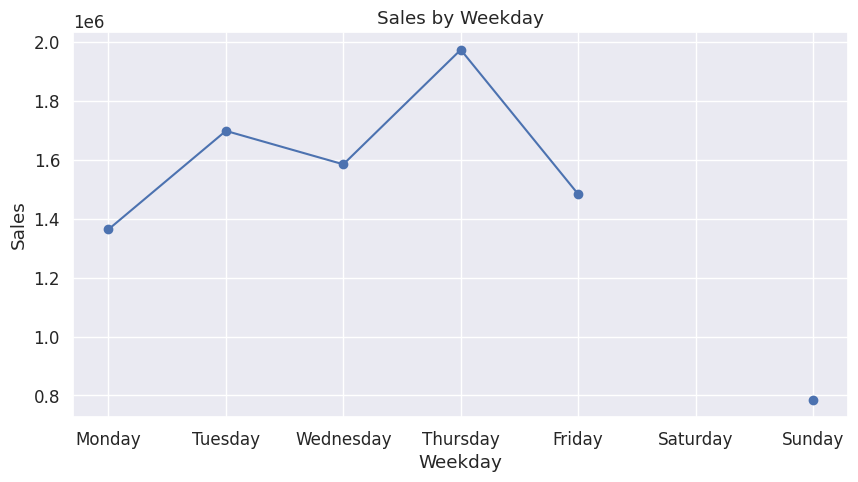

In [37]:
# 10. Sales by Weekday

weekday_order = [

    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"

]

weekday_sales = df.groupby(
    "Weekday"
)["Sales"].sum()

weekday_sales = weekday_sales.reindex(weekday_order)

plt.figure(figsize=(10,5))

weekday_sales.plot(
    marker="o"
)

plt.title("Sales by Weekday")

plt.ylabel("Sales")

plt.show()

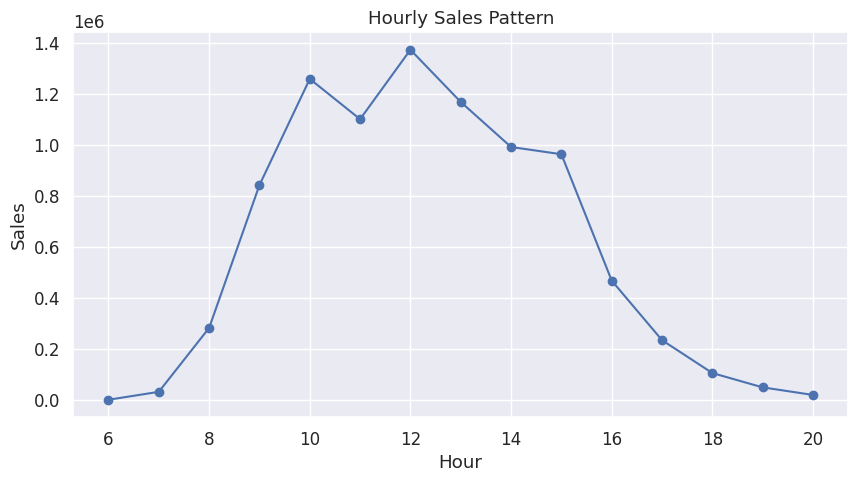

In [38]:
# 11. Sales by Hour

hourly_sales = df.groupby(
    "Hour"
)["Sales"].sum()

plt.figure(figsize=(10,5))

hourly_sales.plot(
    marker="o"
)

plt.title("Hourly Sales Pattern")

plt.xlabel("Hour")

plt.ylabel("Sales")

plt.show()

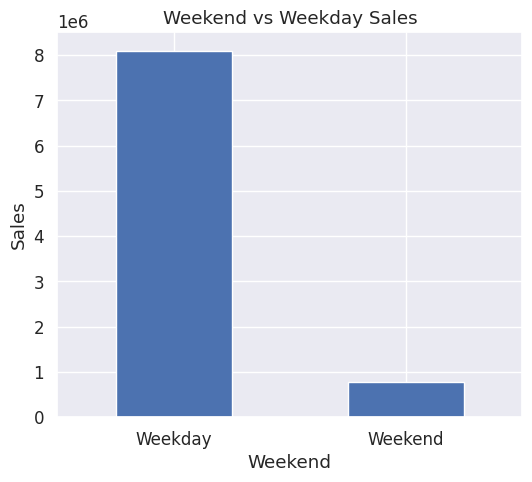

In [39]:
# 12. Weekend vs Weekday

weekend_sales = df.groupby(
    "Weekend"
)["Sales"].sum()

plt.figure(figsize=(6,5))

weekend_sales.plot(
    kind="bar"
)

plt.title("Weekend vs Weekday Sales")

plt.xticks(
    [0,1],
    ["Weekday","Weekend"],
    rotation=0
)

plt.ylabel("Sales")

plt.show()


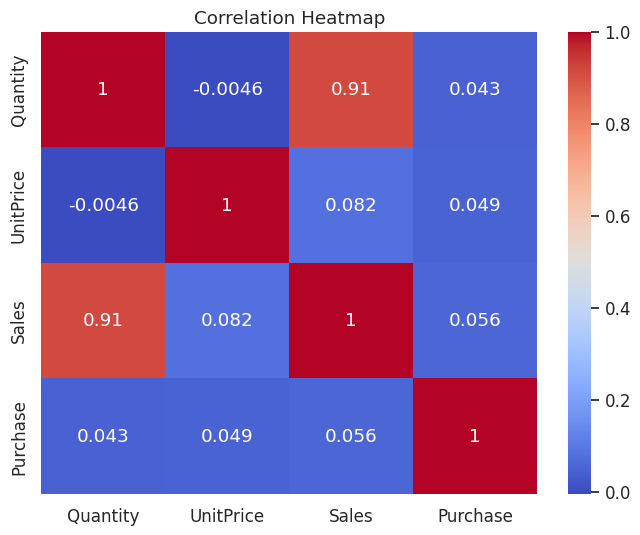

In [40]:
# 13. Correlation Heatmap

numeric = [

    "Quantity",
    "UnitPrice",
    "Sales",
    "Purchase"

]

plt.figure(figsize=(8,6))

sns.heatmap(

    df[numeric].corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Heatmap")

plt.show()

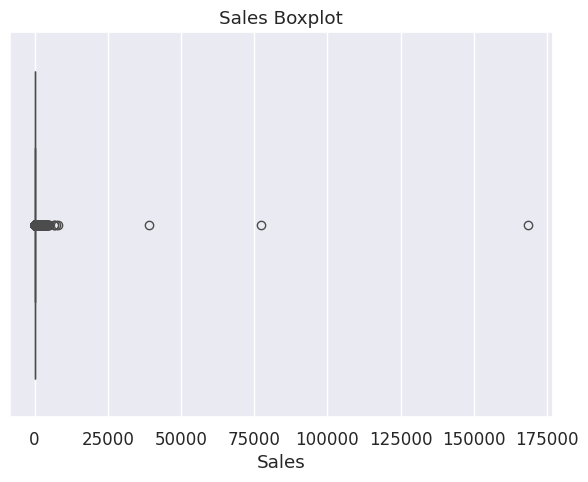

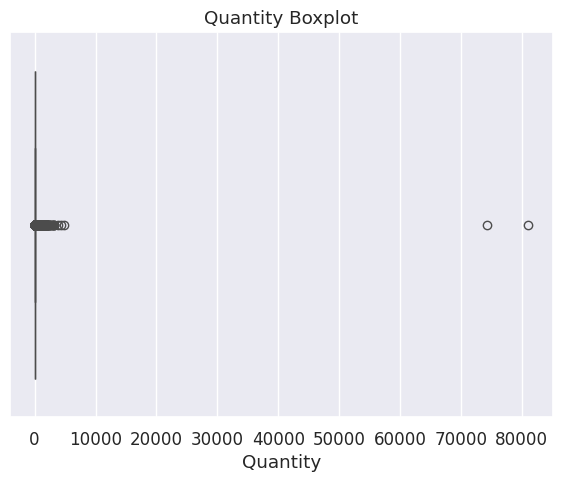

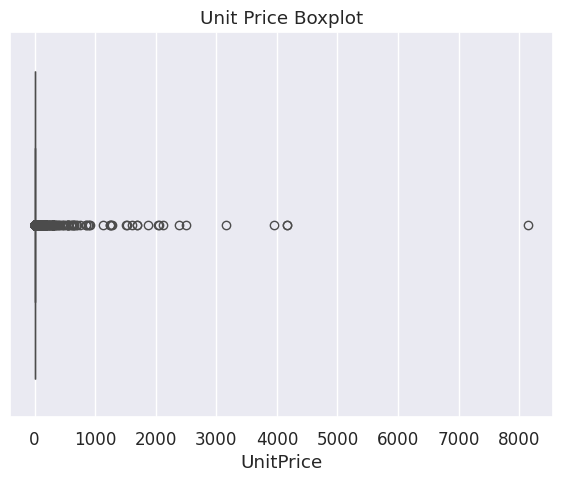

In [41]:
# 14. Boxplots (Outlier Analysis)

plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Boxplot")

plt.show()

plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["Quantity"]
)

plt.title("Quantity Boxplot")

plt.show()

plt.figure(figsize=(7,5))

sns.boxplot(
    x=df["UnitPrice"]
)

plt.title("Unit Price Boxplot")

plt.show()

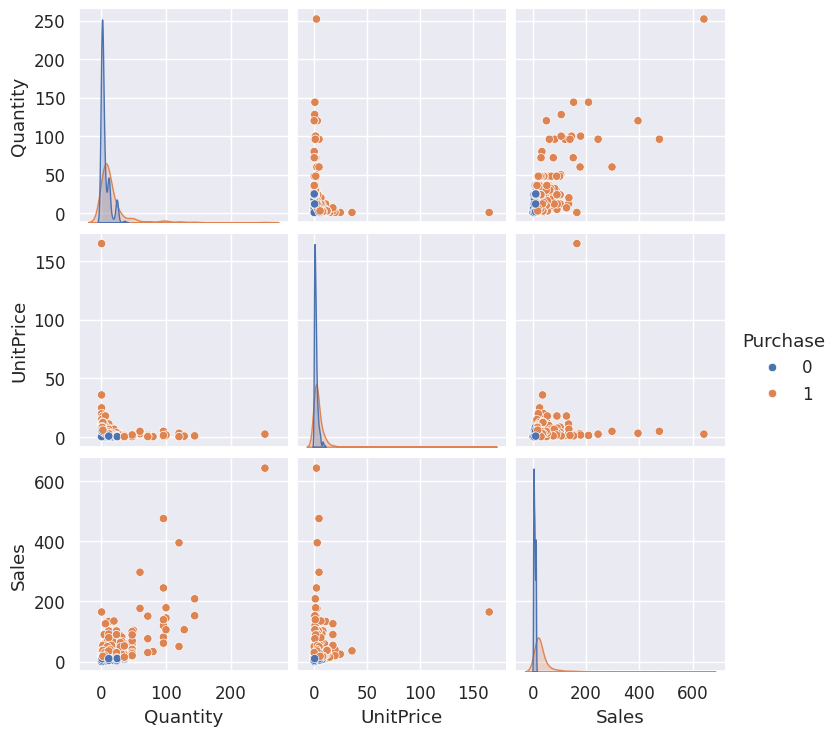

In [42]:
# 15. Pairplot

sample = df.sample(
    1000,
    random_state=42
)

sns.pairplot(

    sample[

        [

            "Quantity",

            "UnitPrice",

            "Sales",

            "Purchase"

        ]

    ],

    hue="Purchase"

)

plt.show()

In [43]:
# Statistical Summary

print("="*70)

print("STATISTICAL SUMMARY")

print("="*70)

display(df.describe())

STATISTICAL SUMMARY


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Sales,Year,Month,Day,Hour,Weekend,Purchase
count,392692.000000,392692.000000,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500,2010.934631,7.601871,15.044656,12.721532,0.155878,0.500008
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000,0.000000,0.000000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000,0.000000,0.000000
50%,561874.000000,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000,2011.000000,8.000000,15.000000,13.000000,0.000000,1.000000
75%,572061.000000,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000,0.000000,1.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000,1.000000,1.000000
std,13087.063759,180.492832,NaN,22.241836,1713.539549,311.099224,0.247177,3.415015,8.652532,2.276661,0.362740,0.500001


In [44]:
# Purchase Behaviour Statistics

purchase_summary = df.groupby(
    "Purchase"
)[

    [

        "Quantity",

        "UnitPrice",

        "Sales"

    ]

].mean()

print("\nPurchase Behaviour Summary")

display(purchase_summary)


Purchase Behaviour Summary


,Quantity,UnitPrice,Sales
Purchase,,,
0,5.290369,2.046987,5.302537
1,20.948795,4.204808,39.959933


In [45]:
# Save EDA Summary

purchase_summary.to_csv(
    "Purchase_Behaviour_Summary.csv"
)

country_sales.to_csv(
    "Country_Sales.csv"
)

top_products.to_csv(
    "Top_Products.csv"
)

top_customers.to_csv(
    "Top_Customers.csv"
)

print("\nEDA Results Saved Successfully")


EDA Results Saved Successfully


In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [47]:
# Load Clean Dataset

df = pd.read_csv("OnlineRetail_Cleaned.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset Loaded Successfully")
print(df.shape)

Dataset Loaded Successfully
(392692, 17)


In [48]:
# Create Customer-Level Features

print("\nCreating Customer Features...")

customer_df = df.groupby("CustomerID").agg(

    TotalSales=("Sales","sum"),

    TotalQuantity=("Quantity","sum"),

    AverageUnitPrice=("UnitPrice","mean"),

    TotalTransactions=("InvoiceNo","nunique"),

    UniqueProducts=("StockCode","nunique"),

    AverageQuantity=("Quantity","mean"),

    AverageTransactionValue=("Sales","mean"),

    FirstPurchase=("InvoiceDate","min"),

    LastPurchase=("InvoiceDate","max")

).reset_index()


Creating Customer Features...


In [49]:
# Customer Active Days

customer_df["DaysActive"] = (

    customer_df["LastPurchase"] -

    customer_df["FirstPurchase"]

).dt.days + 1

In [50]:
# Purchase Frequency

customer_df["PurchaseFrequency"] = (

    customer_df["TotalTransactions"] /

    customer_df["DaysActive"]

)

customer_df["PurchaseFrequency"] = customer_df["PurchaseFrequency"].fillna(0)

In [51]:
# Customer Recency

latest_date = df["InvoiceDate"].max()

customer_df["Recency"] = (

    latest_date -

    customer_df["LastPurchase"]

).dt.days

In [52]:
# High Value Customer Target

median_sales = customer_df["TotalSales"].median()

customer_df["HighValueCustomer"] = np.where(

    customer_df["TotalSales"] >= median_sales,

    1,

    0

)

print("\nTarget Variable Created")

print(customer_df["HighValueCustomer"].value_counts())


Target Variable Created
HighValueCustomer
1    2169
0    2169
Name: count, dtype: int64


In [53]:
# Remove Unnecessary Columns

customer_df = customer_df.drop(

    columns=[

        "FirstPurchase",

        "LastPurchase"

    ]

)

In [54]:
# Dataset Preview

print("\nCustomer Dataset")

display(customer_df.head())

print("\nDataset Shape")

print(customer_df.shape)


Customer Dataset


,CustomerID,TotalSales,TotalQuantity,AverageUnitPrice,TotalTransactions,UniqueProducts,AverageQuantity,AverageTransactionValue,DaysActive,PurchaseFrequency,Recency,HighValueCustomer
0,12346,77183.60,74215,1.040000,1,1,74215.000000,77183.600000,1,1.000000,325,1
1,12347,4310.00,2458,2.644011,7,103,13.505495,23.681319,366,0.019126,1,1
2,12348,1797.24,2341,5.764839,4,22,75.516129,57.975484,283,0.014134,74,1
3,12349,1757.55,631,8.289041,1,73,8.643836,24.076027,1,1.000000,18,1
4,12350,334.40,197,3.841176,1,17,11.588235,19.670588,1,1.000000,309,0



Dataset Shape
(4338, 12)


In [55]:
# Missing Values

print("\nMissing Values")

display(customer_df.isnull().sum())


Missing Values


,0
CustomerID,0
TotalSales,0
TotalQuantity,0
AverageUnitPrice,0
TotalTransactions,0
UniqueProducts,0
AverageQuantity,0
AverageTransactionValue,0
DaysActive,0
PurchaseFrequency,0


In [56]:
# Feature List

features = [

    "TotalSales",

    "TotalQuantity",

    "AverageUnitPrice",

    "TotalTransactions",

    "UniqueProducts",

    "AverageQuantity",

    "AverageTransactionValue",

    "DaysActive",

    "PurchaseFrequency",

    "Recency"

]

X = customer_df[features]

y = customer_df["HighValueCustomer"]

In [57]:
# Feature Summary

summary = pd.DataFrame({

    "Feature":features,

    "Mean":X.mean(),

    "Std":X.std(),

    "Minimum":X.min(),

    "Maximum":X.max()

})

print("\nFeature Summary")

display(summary)


Feature Summary


,Feature,Mean,Std,Minimum,Maximum
TotalSales,TotalSales,2048.688081,8985.230220,3.750000,280206.02
TotalQuantity,TotalQuantity,1187.644537,5043.619654,1.000000,196915.00
AverageUnitPrice,AverageUnitPrice,4.470820,34.215024,0.122500,2033.10
TotalTransactions,TotalTransactions,4.272015,7.697998,1.000000,209.00
UniqueProducts,UniqueProducts,61.501153,85.366768,1.000000,1787.00
AverageQuantity,AverageQuantity,45.080599,1203.437983,1.000000,74215.00
AverageTransactionValue,AverageTransactionValue,68.381590,1467.918294,2.136970,77183.60
DaysActive,DaysActive,131.448594,132.039554,1.000000,374.00
PurchaseFrequency,PurchaseFrequency,0.406695,0.571636,0.005464,17.00
Recency,Recency,91.536422,100.014169,0.000000,373.00


In [58]:
# Correlation Matrix

print("\nCorrelation Matrix")

display(X.corr())


Correlation Matrix


,TotalSales,TotalQuantity,AverageUnitPrice,TotalTransactions,UniqueProducts,AverageQuantity,AverageTransactionValue,DaysActive,PurchaseFrequency,Recency
TotalSales,1.000000,0.922942,0.013402,0.552780,0.385826,0.222435,0.287418,0.225374,-0.088141,-0.121831
TotalQuantity,0.922942,1.000000,-0.005070,0.557216,0.408819,0.298248,0.326377,0.228579,-0.095529,-0.123449
AverageUnitPrice,0.013402,-0.005070,1.000000,-0.010771,-0.028277,0.002390,0.050102,-0.027945,0.035255,0.017353
TotalTransactions,0.552780,0.557216,-0.010771,1.000000,0.692223,-0.006001,-0.005199,0.476560,-0.208294,-0.260578
UniqueProducts,0.385826,0.408819,-0.028277,0.692223,1.000000,-0.019743,-0.023459,0.458102,-0.273429,-0.300728
AverageQuantity,0.222435,0.298248,0.002390,-0.006001,-0.019743,1.000000,0.950082,-0.011657,0.012468,0.030704
AverageTransactionValue,0.287418,0.326377,0.050102,-0.005199,-0.023459,0.950082,1.000000,-0.010106,0.017964,0.024610
DaysActive,0.225374,0.228579,-0.027945,0.476560,0.458102,-0.011657,-0.010106,1.000000,-0.651825,-0.513562
PurchaseFrequency,-0.088141,-0.095529,0.035255,-0.208294,-0.273429,0.012468,0.017964,-0.651825,1.000000,0.412094
Recency,-0.121831,-0.123449,0.017353,-0.260578,-0.300728,0.030704,0.024610,-0.513562,0.412094,1.000000


In [59]:
# Standardisation

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(

    X_scaled,

    columns=features

)

In [60]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Shape")

print(X_train.shape)

print("\nTesting Shape")

print(X_test.shape)


Training Shape
(3470, 10)

Testing Shape
(868, 10)


In [61]:
# Save Processed Dataset

processed = X_scaled.copy()

processed["HighValueCustomer"] = y

processed.to_csv(

    "Customer_ML_Dataset.csv",

    index=False

)

print("\nMachine Learning Dataset Saved")


Machine Learning Dataset Saved


In [62]:
# Save Train Test Files

X_train.to_csv("X_train.csv",index=False)

X_test.to_csv("X_test.csv",index=False)

y_train.to_csv("y_train.csv",index=False)

y_test.to_csv("y_test.csv",index=False)

print("\nTraining and Testing Files Saved")


Training and Testing Files Saved


In [63]:
# Dataset Statistics

print("="*70)

print("CUSTOMER DATASET SUMMARY")

print("="*70)

print("Total Customers :",len(customer_df))

print("Features :",len(features))

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

print("\nTarget Distribution")

print(y.value_counts())

CUSTOMER DATASET SUMMARY
Total Customers : 4338
Features : 10
Training Samples : 3470
Testing Samples : 868

Target Distribution
HighValueCustomer
1    2169
0    2169
Name: count, dtype: int64


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import (
    cross_val_score,
    learning_curve
)

import joblib

print("="*70)
print("LOGISTIC REGRESSION MODEL")
print("="*70)

LOGISTIC REGRESSION MODEL


In [65]:
# Build Model

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [66]:
# Train Model

lr_model.fit(X_train, y_train)

print("\nModel Trained Successfully")


Model Trained Successfully


In [67]:
# Prediction

y_pred_lr = lr_model.predict(X_test)

y_prob_lr = lr_model.predict_proba(X_test)[:,1]

In [68]:
# Evaluation Metrics

accuracy_lr = accuracy_score(y_test,y_pred_lr)

precision_lr = precision_score(y_test,y_pred_lr)

recall_lr = recall_score(y_test,y_pred_lr)

f1_lr = f1_score(y_test,y_pred_lr)

auc_lr = roc_auc_score(y_test,y_prob_lr)

print("\n==============================")
print("Logistic Regression Results")
print("==============================")

print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC AUC   : {auc_lr:.4f}")


Logistic Regression Results
Accuracy  : 0.9171
Precision : 0.9249
Recall    : 0.9078
F1 Score  : 0.9163
ROC AUC   : 0.9782


In [69]:
# Classification Report

print("\nClassification Report")

print(classification_report(
    y_test,
    y_pred_lr
))


Classification Report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       434
           1       0.92      0.91      0.92       434

    accuracy                           0.92       868
   macro avg       0.92      0.92      0.92       868
weighted avg       0.92      0.92      0.92       868



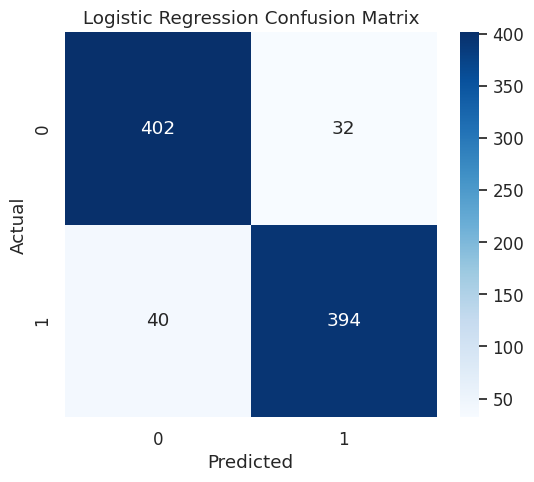

In [70]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

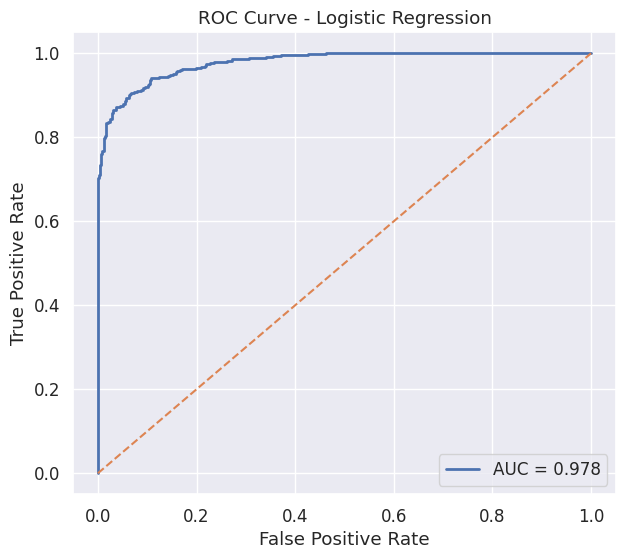

In [71]:
# ROC Curve

fpr,tpr,threshold = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_lr:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [72]:
# Cross Validation

cv_scores = cross_val_score(

    lr_model,

    X_train,

    y_train,

    cv=5,

    scoring="accuracy"

)

print("\nCross Validation Accuracy")

print(cv_scores)

print("\nAverage CV Accuracy")

print(cv_scores.mean())


Cross Validation Accuracy
[0.92651297 0.93227666 0.91210375 0.91354467 0.91930836]

Average CV Accuracy
0.920749279538905


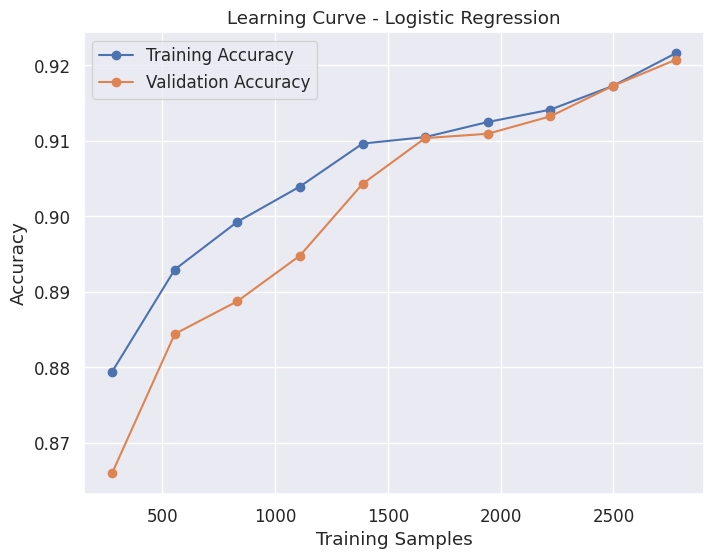

In [73]:
# Learning Curve

train_sizes,train_scores,test_scores = learning_curve(

    lr_model,

    X_train,

    y_train,

    cv=5,

    scoring="accuracy",

    train_sizes=np.linspace(
        0.1,
        1.0,
        10
    )

)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(

    train_sizes,

    train_mean,

    marker="o",

    label="Training Accuracy"

)

plt.plot(

    train_sizes,

    test_mean,

    marker="o",

    label="Validation Accuracy"

)

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Learning Curve - Logistic Regression")

plt.legend()

plt.grid(True)

plt.show()


Feature Importance


,Feature,Coefficient
0,TotalSales,13.855037
1,TotalQuantity,9.053307
3,TotalTransactions,3.163870
6,AverageTransactionValue,2.840538
4,UniqueProducts,1.415959
7,DaysActive,0.022751
2,AverageUnitPrice,0.014633
9,Recency,-0.090859
8,PurchaseFrequency,-0.314691
5,AverageQuantity,-1.286736


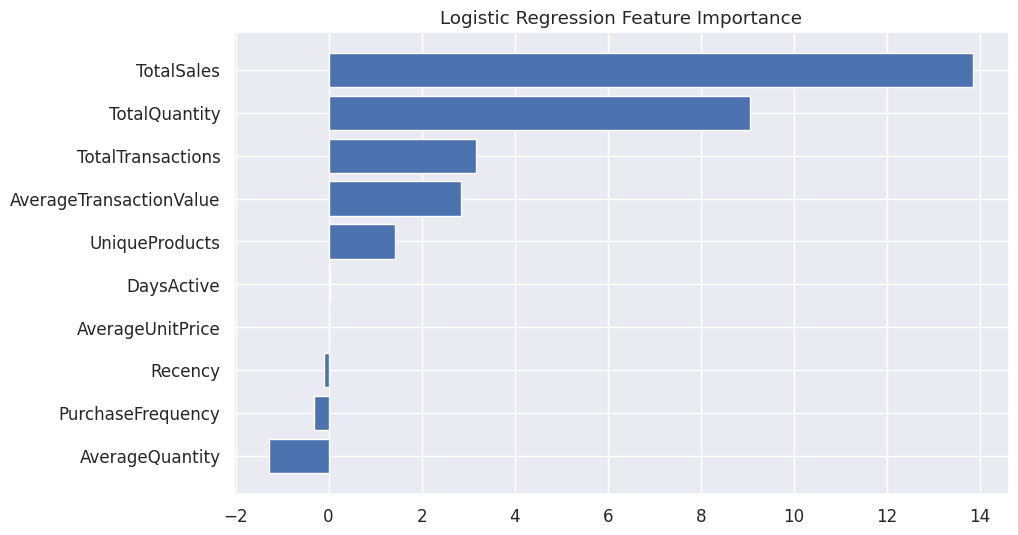

In [74]:
# Feature Importance (Coefficients)

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Coefficient":lr_model.coef_[0]

})

importance = importance.sort_values(

    by="Coefficient",

    ascending=False

)

print("\nFeature Importance")

display(importance)

plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Coefficient"]

)

plt.title("Logistic Regression Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [75]:
# Save Model

joblib.dump(

    lr_model,

    "LogisticRegression_Model.pkl"

)

print("\nModel Saved Successfully")


Model Saved Successfully


In [76]:
# Save Results

lr_results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"

    ],

    "Value":[

        accuracy_lr,

        precision_lr,

        recall_lr,

        f1_lr,

        auc_lr

    ]

})

display(lr_results)

lr_results.to_csv(

    "LogisticRegression_Results.csv",

    index=False

)

,Metric,Value
0,Accuracy,0.917051
1,Precision,0.924883
2,Recall,0.907834
3,F1 Score,0.916279
4,ROC AUC,0.978206


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)


Training Decision Tree Model...

Best Parameters
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree Performance
Accuracy  : 0.9977
Precision : 0.9954
Recall    : 1.0000
F1 Score  : 0.9977
ROC AUC   : 0.9977
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       434
           1       1.00      1.00      1.00       434

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



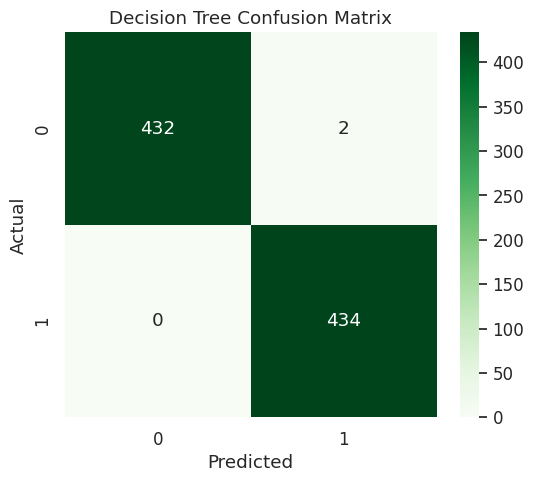

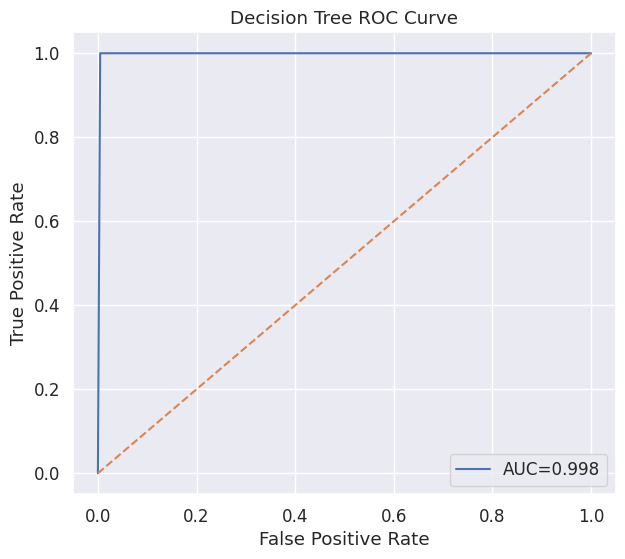


Decision Tree CV Accuracy
[1.         1.         1.         0.99855908 0.99855908]
Mean : 0.9994236311239193


,Feature,Importance
0,TotalSales,1.0
1,TotalQuantity,0.0
2,AverageUnitPrice,0.0
3,TotalTransactions,0.0
4,UniqueProducts,0.0
5,AverageQuantity,0.0
6,AverageTransactionValue,0.0
7,DaysActive,0.0
8,PurchaseFrequency,0.0
9,Recency,0.0


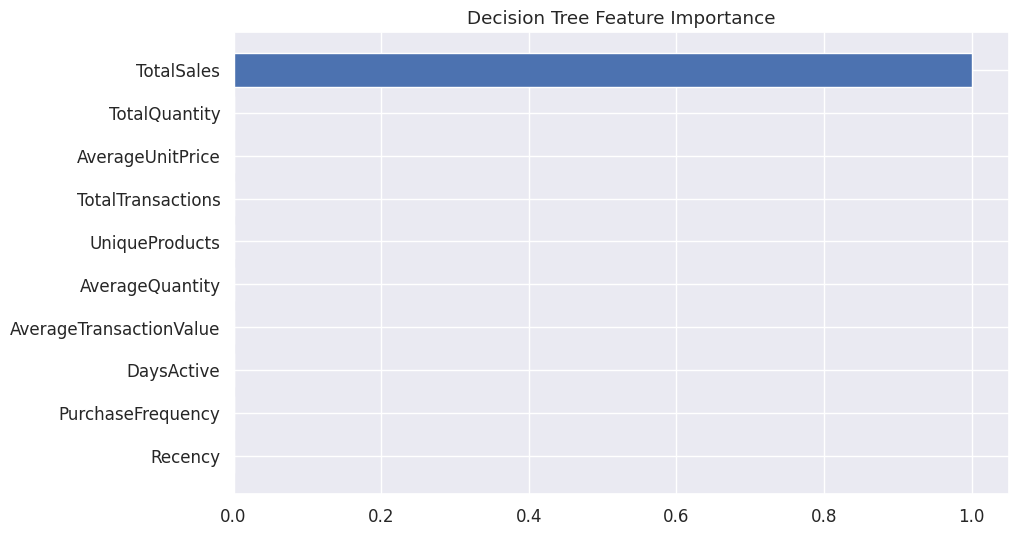

Decision Tree Model Saved


In [80]:
# DECISION TREE

print("\nTraining Decision Tree Model...")

dt_model = DecisionTreeClassifier(
    random_state=42
)

# ---------------- Hyperparameter Tuning -------------------

dt_parameters = {

    "criterion":["gini","entropy"],

    "max_depth":[3,5,7,10,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

dt_grid = GridSearchCV(

    estimator=dt_model,

    param_grid=dt_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

dt_grid.fit(X_train,y_train)

dt_best = dt_grid.best_estimator_

print("\nBest Parameters")

print(dt_grid.best_params_)

# ---------------- Prediction ----------------

y_pred_dt = dt_best.predict(X_test)

y_prob_dt = dt_best.predict_proba(X_test)[:,1]

# ---------------- Metrics ----------------

accuracy_dt = accuracy_score(y_test,y_pred_dt)

precision_dt = precision_score(y_test,y_pred_dt)

recall_dt = recall_score(y_test,y_pred_dt)

f1_dt = f1_score(y_test,y_pred_dt)

auc_dt = roc_auc_score(y_test,y_prob_dt)

print("\nDecision Tree Performance")

print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")
print(f"ROC AUC   : {auc_dt:.4f}")

# ---------------- Classification Report ----------------

print(classification_report(y_test,y_pred_dt))

# ---------------- Confusion Matrix ----------------

cm_dt = confusion_matrix(y_test,y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm_dt,

    annot=True,

    fmt="d",

    cmap="Greens"

)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ---------------- ROC Curve ----------------

fpr_dt,tpr_dt,_ = roc_curve(

    y_test,

    y_prob_dt

)

plt.figure(figsize=(7,6))

plt.plot(fpr_dt,tpr_dt,label=f"AUC={auc_dt:.3f}")

plt.plot([0,1],[0,1],"--")

plt.title("Decision Tree ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# ---------------- Cross Validation ----------------

dt_cv = cross_val_score(

    dt_best,

    X_train,

    y_train,

    cv=5,

    scoring="accuracy"

)

print("\nDecision Tree CV Accuracy")

print(dt_cv)

print("Mean :",dt_cv.mean())

# ---------------- Feature Importance ----------------

dt_importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":dt_best.feature_importances_

})

dt_importance = dt_importance.sort_values(

    by="Importance",

    ascending=False

)

display(dt_importance)

plt.figure(figsize=(10,6))

plt.barh(

    dt_importance["Feature"],

    dt_importance["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Decision Tree Feature Importance")

plt.show()

joblib.dump(dt_best,"DecisionTree_Model.pkl")

print("Decision Tree Model Saved")


Training Random Forest Model...

Best Parameters
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Performance
Accuracy  : 0.9977
Precision : 0.9954
Recall    : 1.0000
F1 Score  : 0.9977
ROC AUC   : 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       434
           1       1.00      1.00      1.00       434

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



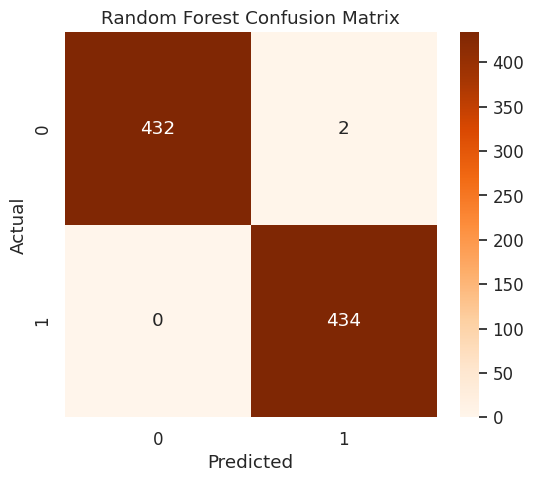

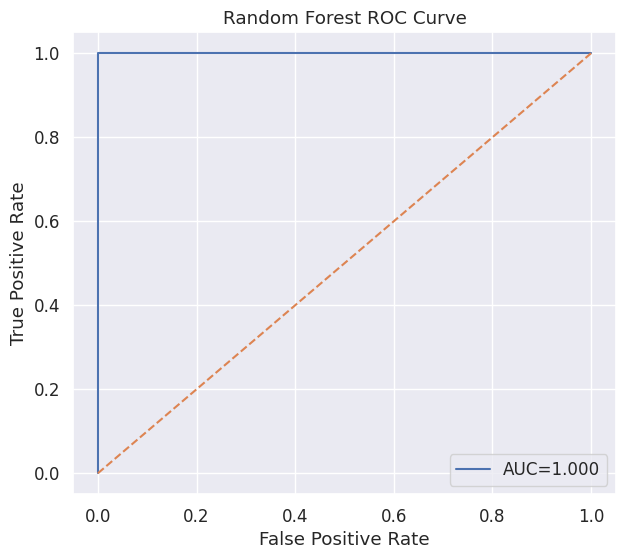


Random Forest CV Accuracy
[1.         1.         1.         0.99855908 0.99855908]
Mean : 0.9994236311239193


,Feature,Importance
0,TotalSales,0.544956
1,TotalQuantity,0.215337
3,TotalTransactions,0.078205
4,UniqueProducts,0.062758
7,DaysActive,0.049838
8,PurchaseFrequency,0.023383
6,AverageTransactionValue,0.011213
5,AverageQuantity,0.006396
2,AverageUnitPrice,0.005703
9,Recency,0.002211


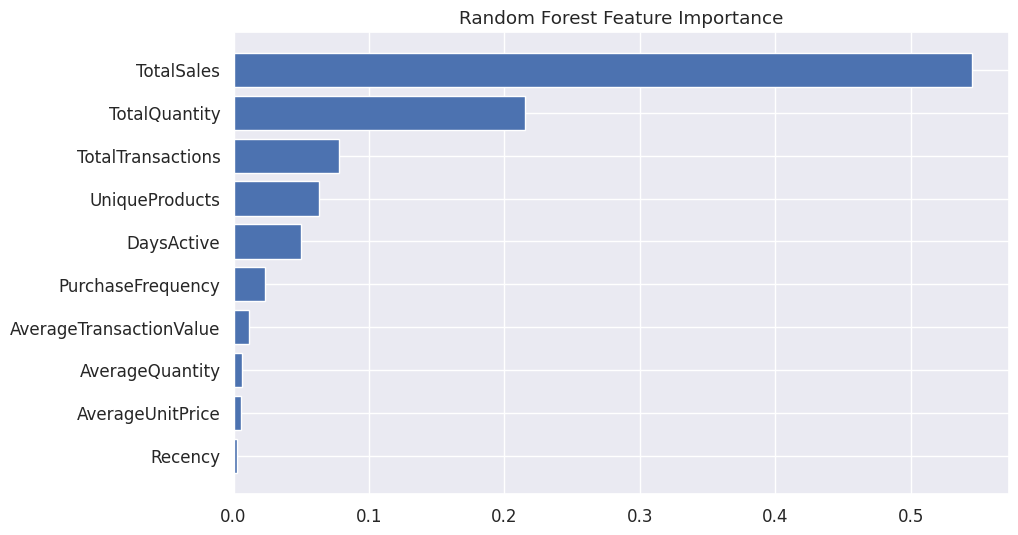

Random Forest Model Saved


In [81]:
# RANDOM FOREST

print("\nTraining Random Forest Model...")

rf_model = RandomForestClassifier(
    random_state=42
)

rf_parameters = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

rf_grid = GridSearchCV(

    estimator=rf_model,

    param_grid=rf_parameters,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

rf_grid.fit(X_train,y_train)

rf_best = rf_grid.best_estimator_

print("\nBest Parameters")

print(rf_grid.best_params_)

# ---------------- Prediction ----------------

y_pred_rf = rf_best.predict(X_test)

y_prob_rf = rf_best.predict_proba(X_test)[:,1]

# ---------------- Metrics ----------------

accuracy_rf = accuracy_score(y_test,y_pred_rf)

precision_rf = precision_score(y_test,y_pred_rf)

recall_rf = recall_score(y_test,y_pred_rf)

f1_rf = f1_score(y_test,y_pred_rf)

auc_rf = roc_auc_score(y_test,y_prob_rf)

print("\nRandom Forest Performance")

print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC AUC   : {auc_rf:.4f}")

print(classification_report(y_test,y_pred_rf))

# ---------------- Confusion Matrix ----------------

cm_rf = confusion_matrix(y_test,y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm_rf,

    annot=True,

    fmt="d",

    cmap="Oranges"

)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ---------------- ROC Curve ----------------

fpr_rf,tpr_rf,_ = roc_curve(

    y_test,

    y_prob_rf

)

plt.figure(figsize=(7,6))

plt.plot(fpr_rf,tpr_rf,label=f"AUC={auc_rf:.3f}")

plt.plot([0,1],[0,1],"--")

plt.title("Random Forest ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# ---------------- Cross Validation ----------------

rf_cv = cross_val_score(

    rf_best,

    X_train,

    y_train,

    cv=5,

    scoring="accuracy"

)

print("\nRandom Forest CV Accuracy")

print(rf_cv)

print("Mean :",rf_cv.mean())

# ---------------- Feature Importance ----------------

rf_importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf_best.feature_importances_

})

rf_importance = rf_importance.sort_values(

    by="Importance",

    ascending=False

)

display(rf_importance)

plt.figure(figsize=(10,6))

plt.barh(

    rf_importance["Feature"],

    rf_importance["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.show()

joblib.dump(rf_best,"RandomForest_Model.pkl")

print("Random Forest Model Saved")

In [82]:
# Save Results

model_results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        accuracy_lr,

        accuracy_dt,

        accuracy_rf

    ],

    "Precision":[

        precision_lr,

        precision_dt,

        precision_rf

    ],

    "Recall":[

        recall_lr,

        recall_dt,

        recall_rf

    ],

    "F1 Score":[

        f1_lr,

        f1_dt,

        f1_rf

    ],

    "ROC AUC":[

        auc_lr,

        auc_dt,

        auc_rf

    ]

})

display(model_results)

model_results.to_csv(

    "Model_Comparison.csv",

    index=False

)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.917051,0.924883,0.907834,0.916279,0.978206
1,Decision Tree,0.997696,0.995413,1.000000,0.997701,0.997696
2,Random Forest,0.997696,0.995413,1.000000,0.997701,1.000000


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [84]:
# Create Comparison Table

comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest"

    ],

    "Accuracy":[

        accuracy_lr,

        accuracy_dt,

        accuracy_rf

    ],

    "Precision":[

        precision_lr,

        precision_dt,

        precision_rf

    ],

    "Recall":[

        recall_lr,

        recall_dt,

        recall_rf

    ],

    "F1 Score":[

        f1_lr,

        f1_dt,

        f1_rf

    ],

    "ROC AUC":[

        auc_lr,

        auc_dt,

        auc_rf

    ]

})

print("\nModel Comparison")

display(comparison)

comparison.to_csv(

    "Final_Model_Comparison.csv",

    index=False

)


Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.917051,0.924883,0.907834,0.916279,0.978206
1,Decision Tree,0.997696,0.995413,1.000000,0.997701,0.997696
2,Random Forest,0.997696,0.995413,1.000000,0.997701,1.000000


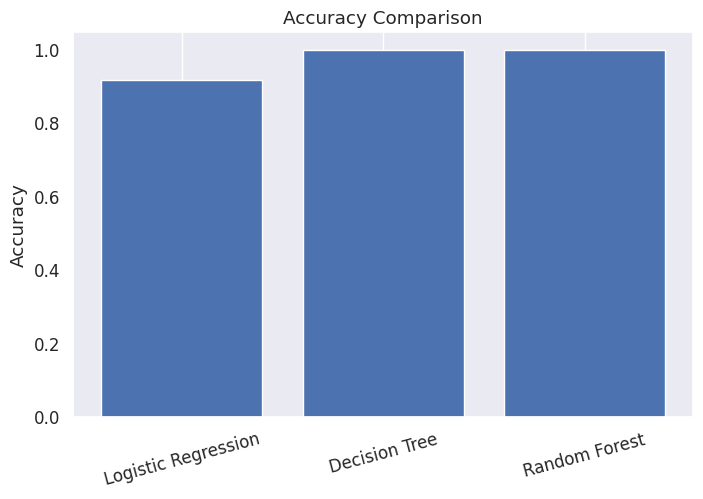

In [85]:
# Accuracy Comparison

plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["Accuracy"]

)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

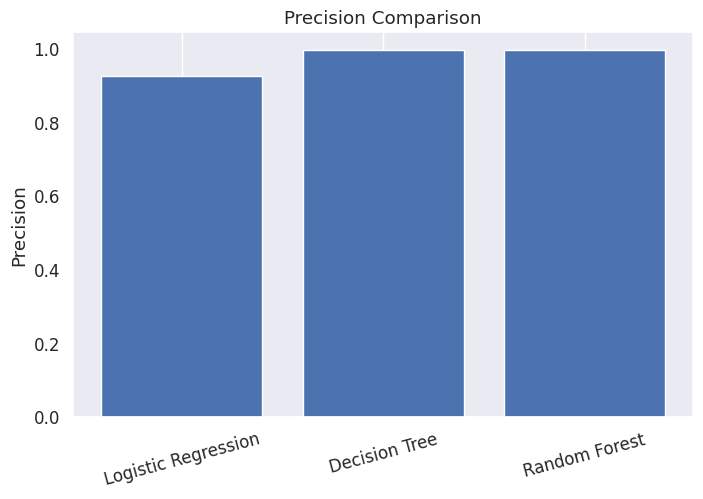

In [86]:
# Precision Comparison

plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["Precision"]

)

plt.ylabel("Precision")

plt.title("Precision Comparison")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

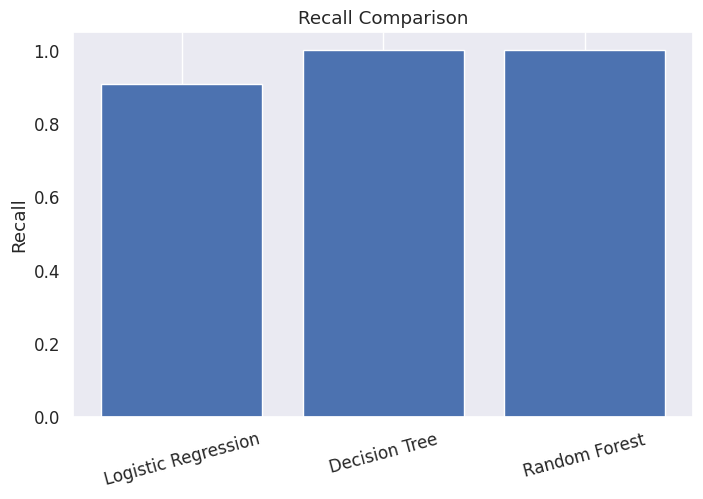

In [87]:
# Recall Comparison

plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["Recall"]

)

plt.ylabel("Recall")

plt.title("Recall Comparison")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

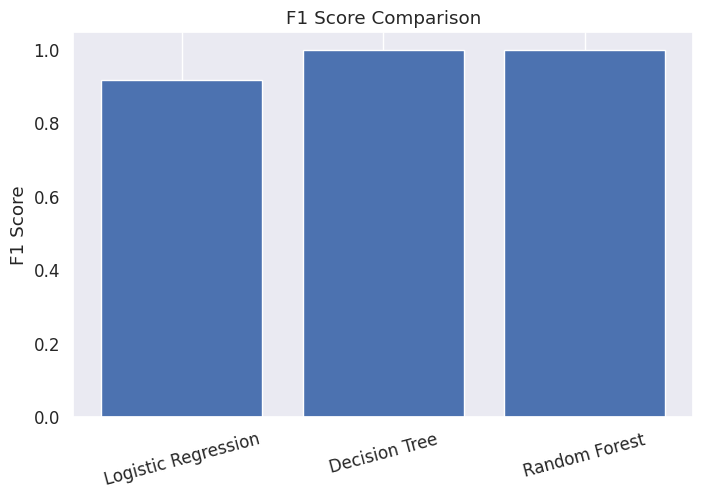

In [88]:
# F1 Score Comparison

plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["F1 Score"]

)

plt.ylabel("F1 Score")

plt.title("F1 Score Comparison")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

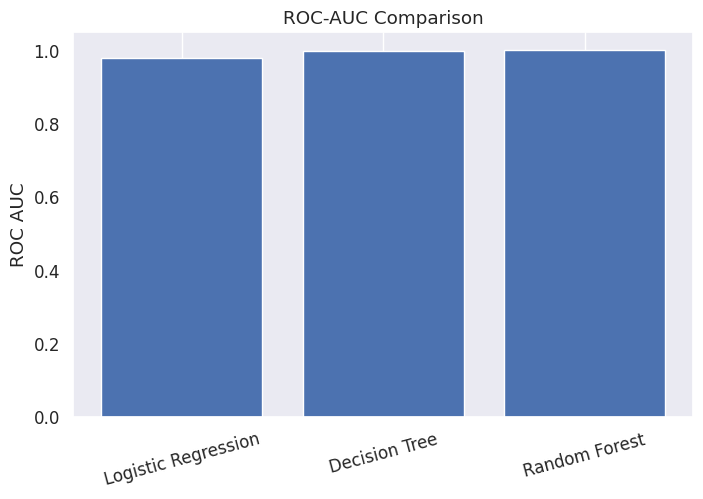

In [89]:
# ROC AUC Comparison

plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["ROC AUC"]

)

plt.ylabel("ROC AUC")

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

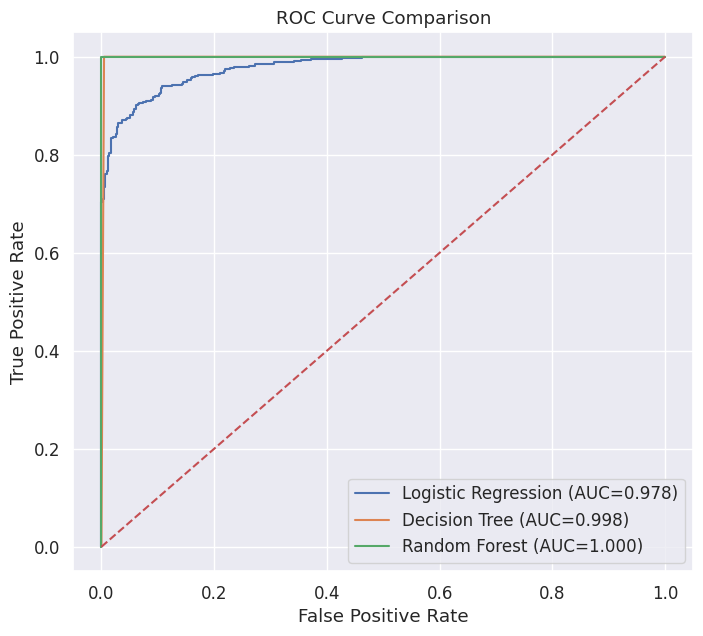

In [90]:
# Combined ROC Curves

plt.figure(figsize=(8,7))

plt.plot(

    fpr,

    tpr,

    label=f"Logistic Regression (AUC={auc_lr:.3f})"

)

plt.plot(

    fpr_dt,

    tpr_dt,

    label=f"Decision Tree (AUC={auc_dt:.3f})"

)

plt.plot(

    fpr_rf,

    tpr_rf,

    label=f"Random Forest (AUC={auc_rf:.3f})"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

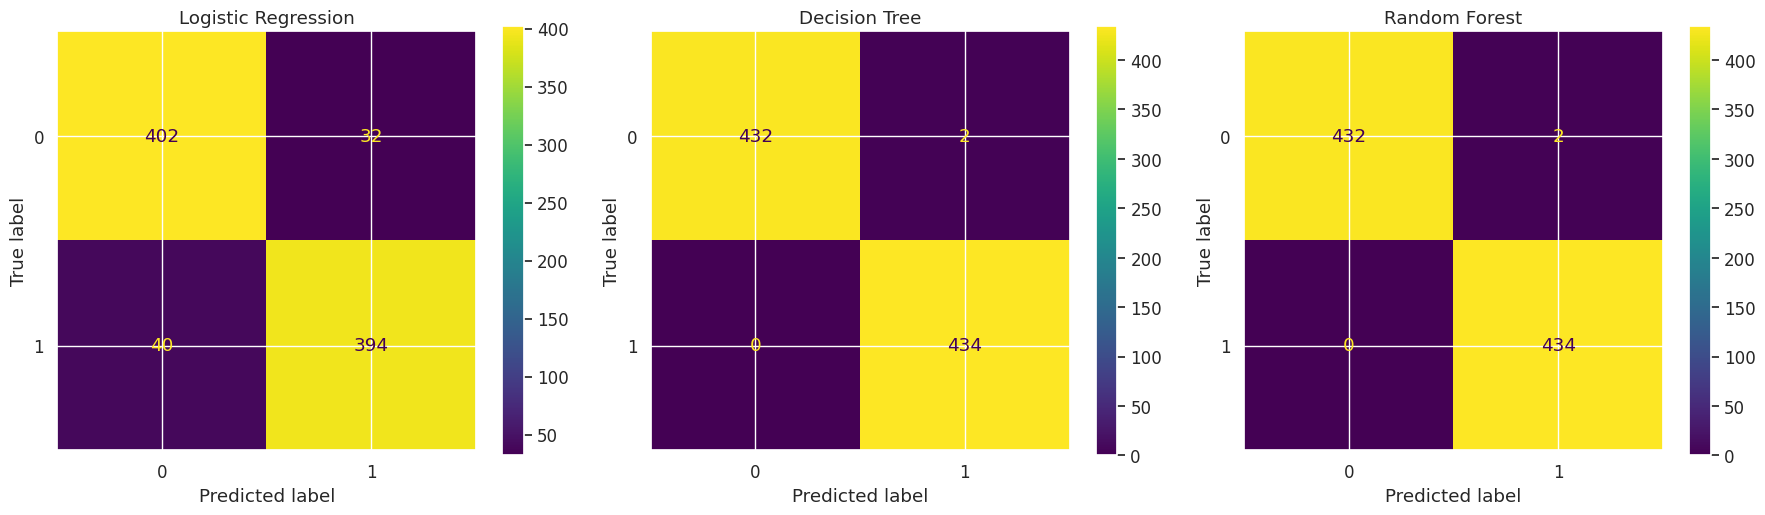

In [91]:
# Confusion Matrices Together

fig, axes = plt.subplots(1,3,figsize=(18,5))

ConfusionMatrixDisplay(cm).plot(ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(cm_dt).plot(ax=axes[1])
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(cm_rf).plot(ax=axes[2])
axes[2].set_title("Random Forest")

plt.tight_layout()

plt.show()

In [92]:
# Determine Best Model

best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("="*70)

print("BEST MODEL")

print("="*70)

print(best_model)

BEST MODEL
Model        Decision Tree
Accuracy          0.997696
Precision         0.995413
Recall                 1.0
F1 Score          0.997701
ROC AUC           0.997696
Name: 1, dtype: object


In [93]:
# Ranking

ranking = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

print("\nRanking")

display(ranking)

ranking.to_csv(

    "Model_Ranking.csv",

    index=False

)


Ranking


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,0.997696,0.995413,1.000000,0.997701,0.997696
2,Random Forest,0.997696,0.995413,1.000000,0.997701,1.000000
0,Logistic Regression,0.917051,0.924883,0.907834,0.916279,0.978206


In [94]:
# Feature Importance Comparison

feature_compare = pd.DataFrame({

    "Feature":X_train.columns,

    "Logistic Regression":np.abs(lr_model.coef_[0]),

    "Decision Tree":dt_best.feature_importances_,

    "Random Forest":rf_best.feature_importances_

})

display(feature_compare)

feature_compare.to_csv(

    "Feature_Importance_Comparison.csv",

    index=False

)

,Feature,Logistic Regression,Decision Tree,Random Forest
0,TotalSales,13.855037,1.0,0.544956
1,TotalQuantity,9.053307,0.0,0.215337
2,AverageUnitPrice,0.014633,0.0,0.005703
3,TotalTransactions,3.163870,0.0,0.078205
4,UniqueProducts,1.415959,0.0,0.062758
5,AverageQuantity,1.286736,0.0,0.006396
6,AverageTransactionValue,2.840538,0.0,0.011213
7,DaysActive,0.022751,0.0,0.049838
8,PurchaseFrequency,0.314691,0.0,0.023383
9,Recency,0.090859,0.0,0.002211


In [95]:
# Summary Statistics

print("="*70)

print("FINAL SUMMARY")

print("="*70)

print("Number of Customers :",len(y))

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

print("Features Used :",X_train.shape[1])

print("Models Compared : 3")

print("Evaluation Metrics : Accuracy, Precision, Recall, F1, ROC-AUC")

FINAL SUMMARY
Number of Customers : 4338
Training Samples : 3470
Testing Samples : 868
Features Used : 10
Models Compared : 3
Evaluation Metrics : Accuracy, Precision, Recall, F1, ROC-AUC
